In [51]:
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [4]:
trainData = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
testData = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(trainData, batch_size=32, shuffle = True, num_workers=2)
test_loader = torch.utils.data.DataLoader(testData, batch_size=32, shuffle = True, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [19]:
image , label = trainData[0]
image.size(), label

(torch.Size([3, 32, 32]), 6)

In [8]:
(len(trainData), len(testData))

(50000, 10000)

In [49]:
class_name = ['plane', 'car','bord','cat','deer','dog','frog','horse','ship','truck']

In [29]:
class NeuralNet(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        #input (3,32,32)
        self.conv1 = nn.Conv2d( 3, 12, 5) #(12,28,28)
        self.pool = nn.MaxPool2d(2,2) # (12,14,14)
        self.conv2 = nn.Conv2d(12,24,5) #(24,10,10) -> (24, 5,5) > flatten (24 * 5*5)
        self.fc1 = nn.Linear(24 * 5 *5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # dim come as (32,24,5,5) so we should get only 24,5,5
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x
    
    
        

In [30]:
net = NeuralNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [31]:
for epoch in range(30):
    print(f"Training epoch {epoch}>")
    
    running_loss = 0
    
    for i, data in enumerate(train_loader):
        inputs, labels = data
        
        optimizer.zero_grad()
        
        outputs  = net(inputs)
        
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f'loss: {running_loss / len(train_loader):.4f}')

Training epoch 0>
loss: 2.2034
Training epoch 1>
loss: 1.7329
Training epoch 2>
loss: 1.5061
Training epoch 3>
loss: 1.3997
Training epoch 4>
loss: 1.3213
Training epoch 5>
loss: 1.2479
Training epoch 6>
loss: 1.1828
Training epoch 7>
loss: 1.1176
Training epoch 8>
loss: 1.0621
Training epoch 9>
loss: 1.0095
Training epoch 10>
loss: 0.9605
Training epoch 11>
loss: 0.9204
Training epoch 12>
loss: 0.8811
Training epoch 13>
loss: 0.8472
Training epoch 14>
loss: 0.8123
Training epoch 15>
loss: 0.7821
Training epoch 16>
loss: 0.7535
Training epoch 17>
loss: 0.7286
Training epoch 18>
loss: 0.7012
Training epoch 19>
loss: 0.6745
Training epoch 20>
loss: 0.6540
Training epoch 21>
loss: 0.6305
Training epoch 22>
loss: 0.6032
Training epoch 23>
loss: 0.5863
Training epoch 24>
loss: 0.5607
Training epoch 25>
loss: 0.5390
Training epoch 26>
loss: 0.5161
Training epoch 27>
loss: 0.5013
Training epoch 28>
loss: 0.4782
Training epoch 29>
loss: 0.4610


In [32]:
torch.save(net.state_dict(), 'trained_net.pth')


In [34]:
net = NeuralNet()
net.load_state_dict(torch.load('trained_net.pth'))

<All keys matched successfully>

In [47]:
correct = 0
total =0

net.eval()

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = net(images)
        # print(outputs)
        _,predict = torch.max(outputs,1)
        # print(predict)
        total += labels.size(0)
        correct += (predict == labels).sum().item()
        
print('Accuracy of the network on the test images: %d %%' % (100 * correct / total))

Accuracy of the network on the test images: 69 %


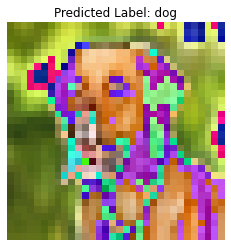

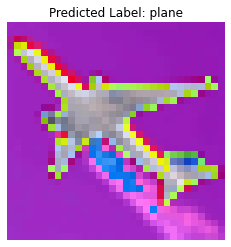

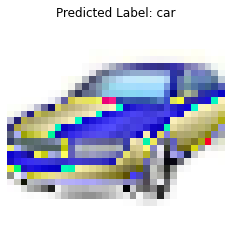

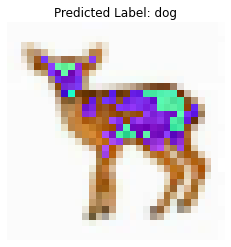

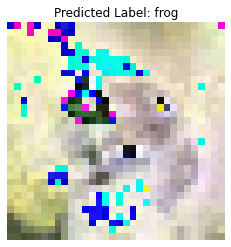

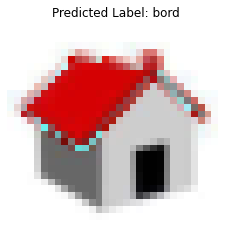

In [69]:
new_trans = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def load_images(imgPath):
    image = Image.open(imgPath)
    image = new_trans(image)
    image = image.unsqueeze(0)
    return image

image_path = ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg']
images = [load_images(img) for img in image_path]

net.eval()

with torch.no_grad():
    for image in images:
        output = net(image)
        _,pred = torch.max(output,1)
        
        img = image.squeeze(0)
        img = transforms.ToPILImage()(img)
        
        plt.imshow(img)
        plt.title(f'Predicted Label: {class_name[pred.item()]}')
        plt.axis('off')
        plt.show()
        # print(f'pred: {class_name[pred.item()]}')